# Lecture 10.1 — K-Means Clustering

---

## What is K-Means Clustering?

Everything we've done so far has been **supervised learning** — we always had
labels telling us the right answer. **Unsupervised learning** is different:
we have data but *no labels*. The goal is to discover hidden structure on our own.

**K-Means Clustering** is the most popular unsupervised algorithm. Given a
dataset and a number k, it groups data into k clusters so that points within
the same cluster are as similar to each other as possible.

### The algorithm — step by step

1. **Initialise** — randomly pick k data points as the starting cluster centers.
2. **Assign** — assign every point to its nearest center (by Euclidean distance).
3. **Update** — move each center to the mean of all points assigned to it.
4. **Repeat** steps 2–3 until the centers stop moving (convergence).

```
Random centers → Assign points → Move centers → Assign points → Move centers → ...
```

---

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme()

---

## Part 1 — Build K-Means from Scratch on Synthetic Data

We follow the professor's lecture exactly — building every piece of the algorithm
step by step on a simple 2D dataset before applying it to real data.


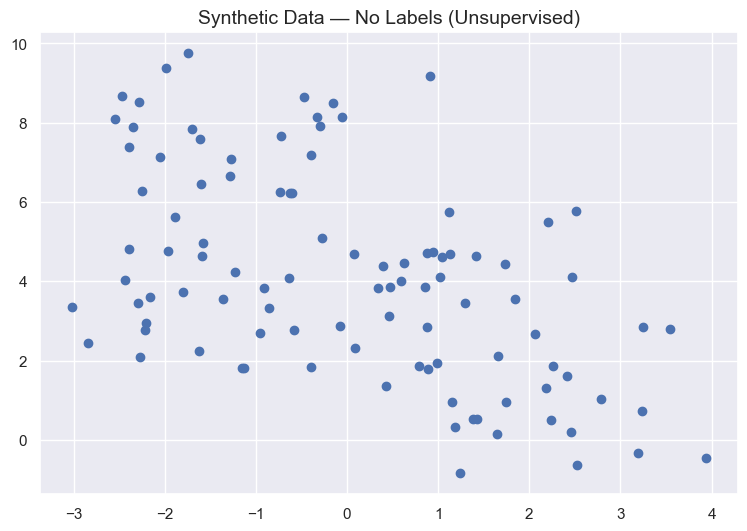

In [2]:
# Generate synthetic blob data — 4 natural clusters, 2 features
# This is exactly what the professor uses in the lecture
X_blob, y_blob = make_blobs(n_samples=100, centers=4, n_features=2, random_state=0)

# Helper to colour points by cluster label (0-3)
def get_color(label):
    """Return a colour string for a given integer cluster label."""
    palette = {0: 'red', 1: 'lightseagreen', 2: 'magenta', 3: 'blue'}
    return palette.get(int(label), 'grey')

# Plot the raw data — no labels (unsupervised setting)
plt.figure(figsize=(9, 6))
plt.scatter(X_blob[:, 0], X_blob[:, 1])
plt.title('Synthetic Data — No Labels (Unsupervised)', fontsize=14)
plt.show()


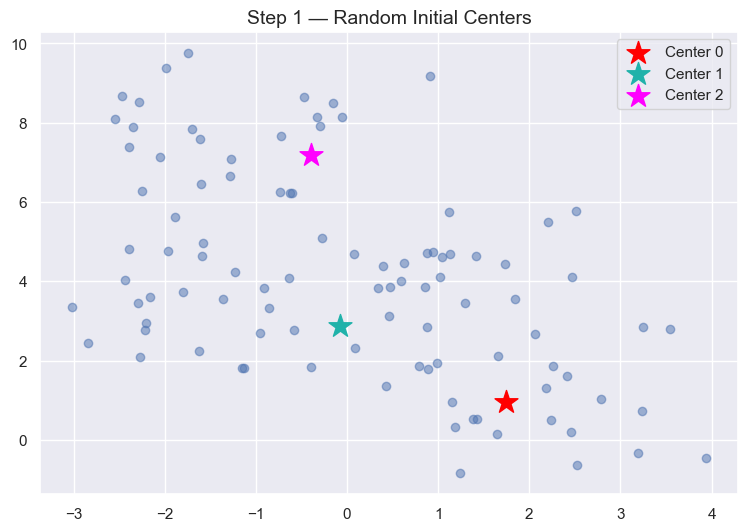


Notice the centers are placed randomly — they don't know anything about
the true clusters yet. The algorithm will move them into position.



In [3]:
# ── Step 1: Randomly pick 3 points as starting centers ───────────────────
np.random.seed(42)
centers = []
for k in range(3):
    i = np.random.randint(0, 100)
    point = (X_blob[i, 0], X_blob[i, 1], k)  # (x, y, cluster_id)
    centers.append(point)

# Plot data with random initial centers marked as stars
plt.figure(figsize=(9, 6))
plt.scatter(X_blob[:, 0], X_blob[:, 1], alpha=0.5)
for center, color in zip(centers, ['red', 'lightseagreen', 'magenta']):
    plt.scatter(center[0], center[1], color=color, s=300,
                marker='*', zorder=5, label=f'Center {center[2]}')
plt.legend()
plt.title('Step 1 — Random Initial Centers', fontsize=14)
plt.show()

print("""
Notice the centers are placed randomly — they don't know anything about
the true clusters yet. The algorithm will move them into position.
""")


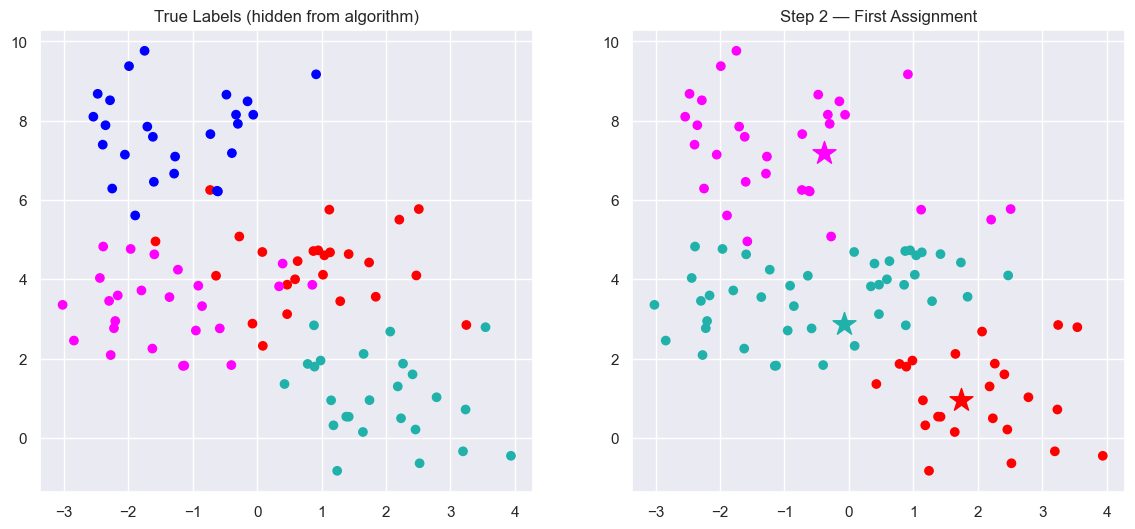

In [4]:
# ── Step 2: Distance function ─────────────────────────────────────────────
# Euclidean distance: sqrt((x1-x2)^2 + (y1-y2)^2)
# This is exactly the professor's distance() function from the lecture
def distance(i, X, center):
    """Compute Euclidean distance from point X[i] to a center."""
    return np.sqrt(sum((X[i, j] - center[j])**2 for j in range(2)))

# ── Step 3: Assign each point to nearest center ───────────────────────────
def assign_label(i, X, centers):
    """Return the index of the nearest center for point X[i]."""
    distances = np.array([distance(i, X, center) for center in centers])
    return np.argmin(distances)

def assign_clusters(X, centers):
    """Assign every point in X to its nearest center."""
    return [assign_label(i, X, centers) for i in range(len(X))]

# Run first assignment and plot side-by-side with true labels
current_labels = assign_clusters(X_blob, centers)
current_colors = [get_color(label) for label in current_labels]
true_colors    = [get_color(label) for label in y_blob]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.scatter(X_blob[:, 0], X_blob[:, 1], c=true_colors)
ax1.set_title('True Labels (hidden from algorithm)', fontsize=12)

ax2.scatter(X_blob[:, 0], X_blob[:, 1], c=current_colors)
for center, color in zip(centers, ['red', 'lightseagreen', 'magenta']):
    ax2.scatter(center[0], center[1], color=color, s=300, marker='*', zorder=5)
ax2.set_title('Step 2 — First Assignment', fontsize=12)
plt.show()


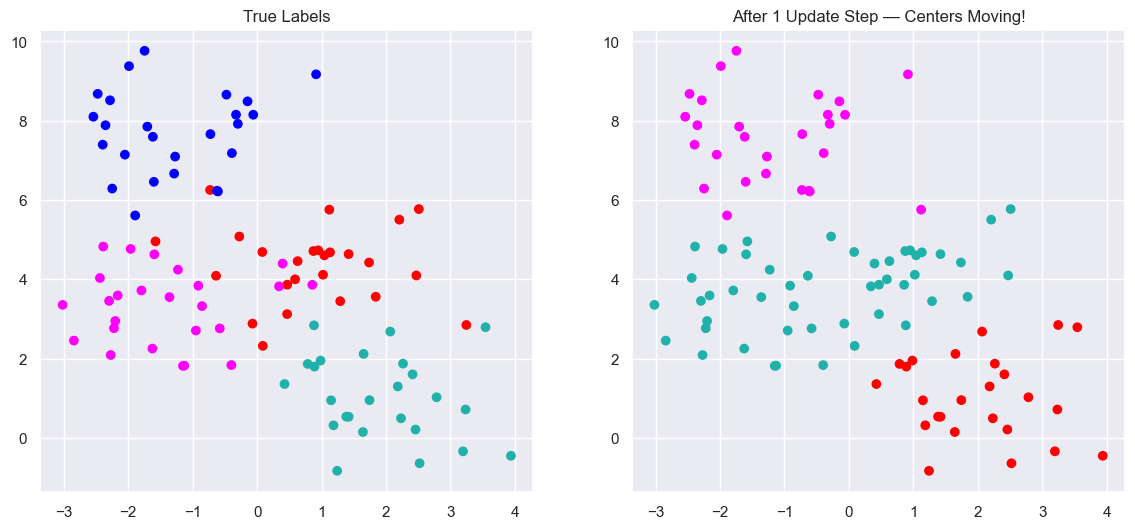

In [5]:
# ── Step 4: Move each center to the mean of its cluster ──────────────────
# This is exactly the professor's update_centers() function
def update_centers(X, centers):
    """Move each center to the mean position of its assigned points."""
    current_labels = assign_clusters(X, centers)
    k = len(centers)

    # Accumulate sums for each cluster
    center_means = {i: [0, 0] for i in range(k)}
    for i in range(len(X)):
        center_means[current_labels[i]][0] += X[i, 0]
        center_means[current_labels[i]][1] += X[i, 1]

    # Divide by count to get the mean
    for i in range(k):
        num_occur = current_labels.count(i)
        center_means[i][0] /= num_occur
        center_means[i][1] /= num_occur

    return [(center_means[i][0], center_means[i][1]) for i in center_means]

# Run one update and plot
new_centers    = update_centers(X_blob, centers)
current_labels = assign_clusters(X_blob, new_centers)
current_colors = [get_color(label) for label in current_labels]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.scatter(X_blob[:, 0], X_blob[:, 1], c=true_colors)
ax1.set_title('True Labels', fontsize=12)
ax2.scatter(X_blob[:, 0], X_blob[:, 1], c=current_colors)
ax2.set_title('After 1 Update Step — Centers Moving!', fontsize=12)
plt.show()


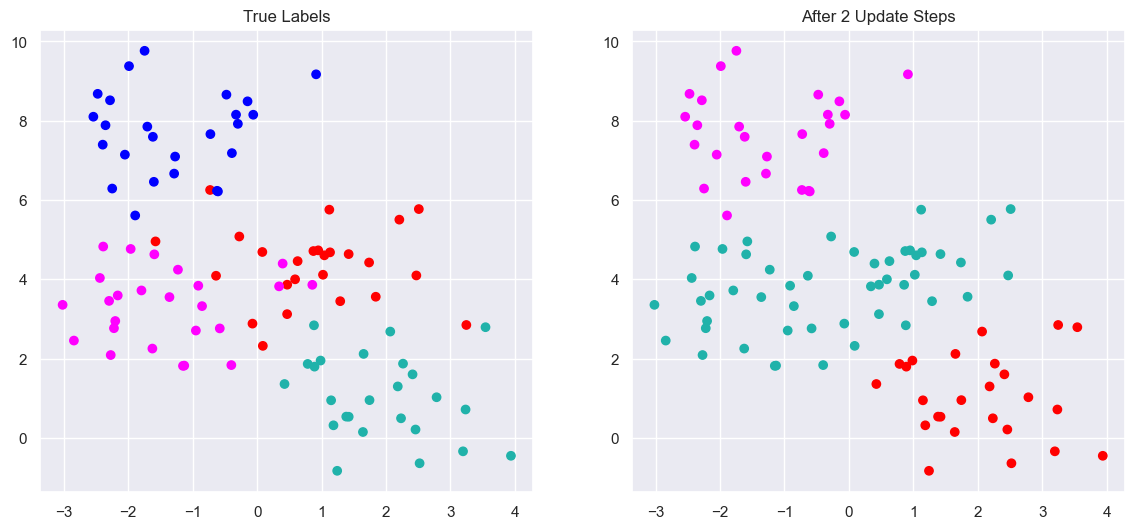

In [6]:
# Run a second update step — centers keep improving
new_centers    = update_centers(X_blob, new_centers)
current_labels = assign_clusters(X_blob, new_centers)
current_colors = [get_color(label) for label in current_labels]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.scatter(X_blob[:, 0], X_blob[:, 1], c=true_colors)
ax1.set_title('True Labels', fontsize=12)
ax2.scatter(X_blob[:, 0], X_blob[:, 1], c=current_colors)
ax2.set_title('After 2 Update Steps', fontsize=12)
plt.show()


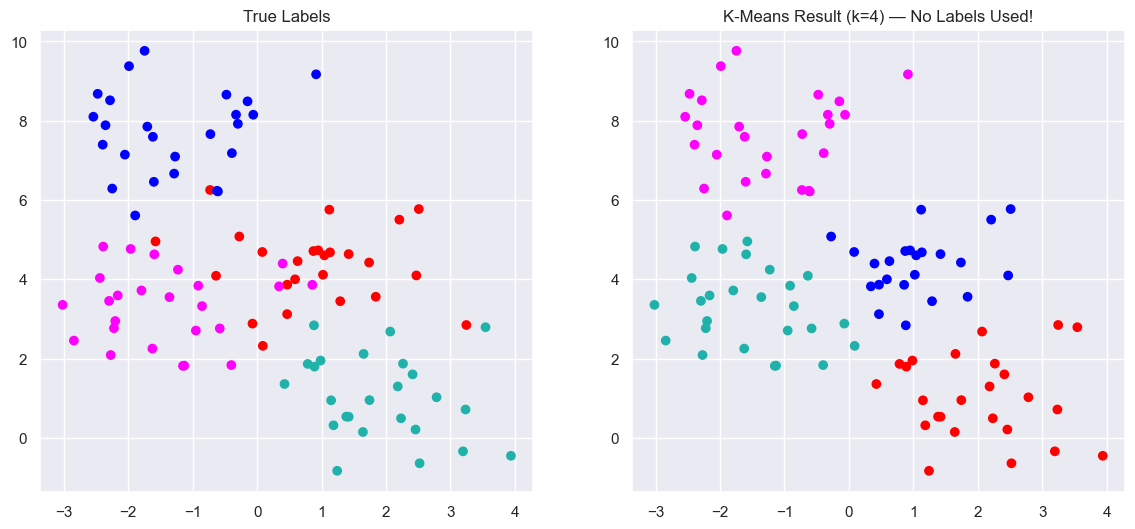

K-Means recovered the 4 clusters without ever seeing the true labels!


In [7]:
# ── Full K-Means function (professor's version) ───────────────────────────
# This ties everything together — init, then repeat assign+update
def k_means_clustering(X, k, max_iter=100):
    """Run k-means and return final cluster centers."""
    centers = []
    for j in range(k):
        i = np.random.randint(0, 100)
        centers.append((X[i, 0], X[i, 1], j))

    for _ in range(max_iter):
        centers = update_centers(X, centers)

    return centers

# Run with k=4 and compare to true labels
np.random.seed(42)
final_centers  = k_means_clustering(X_blob, k=4)
final_labels   = assign_clusters(X_blob, final_centers)
final_colors   = [get_color(label) for label in final_labels]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.scatter(X_blob[:, 0], X_blob[:, 1], c=true_colors)
ax1.set_title('True Labels', fontsize=12)
ax2.scatter(X_blob[:, 0], X_blob[:, 1], c=final_colors)
ax2.set_title('K-Means Result (k=4) — No Labels Used!', fontsize=12)
plt.show()

print("K-Means recovered the 4 clusters without ever seeing the true labels!")


---

## Part 2 — Real Data: Global Tree Cover Loss

Now we apply K-Means to the **Global Tree Cover Loss by Country** dataset.
Each row is a country, and the features are hectares of tree cover lost
each year from 2001 to 2022.

**Goal:** Cluster countries by their deforestation patterns over time.
Do some countries share similar trajectories of forest loss?


In [8]:
# Load the dataset
df = pd.read_csv('data/Tree_Cover_Loss_Country.csv')
print('Shape:', df.shape)
print()
df.head()


Shape: (1888, 28)



,country,threshold,area_ha,extent_2000_ha,extent_2010_ha,gain_2000-2020_ha,tc_loss_ha_2001,tc_loss_ha_2002,tc_loss_ha_2003,tc_loss_ha_2004,...,tc_loss_ha_2013,tc_loss_ha_2014,tc_loss_ha_2015,tc_loss_ha_2016,tc_loss_ha_2017,tc_loss_ha_2018,tc_loss_ha_2019,tc_loss_ha_2020,tc_loss_ha_2021,tc_loss_ha_2022
0,Afghanistan,0,64385715,64385715,64385715,10741,103,214,267,225,...,15,9,0,0,0,32,26,46,47,15
1,Afghanistan,10,64385715,432115,126247,10741,92,190,253,207,...,2,4,0,0,0,28,19,40,37,9
2,Afghanistan,15,64385715,302660,106867,10741,91,186,247,205,...,2,3,0,0,0,28,18,39,32,8
3,Afghanistan,20,64385715,284357,105733,10741,89,180,245,203,...,2,3,0,0,0,28,18,39,32,8
4,Afghanistan,25,64385715,254867,72395,10741,89,180,245,202,...,1,3,0,0,0,27,18,38,28,7


In [9]:
# Filter to threshold = 30 (standard Global Forest Watch threshold)
# This gives one row per country
df30 = df[df['threshold'] == 30].copy()
print('Countries:', len(df30))

# Yearly tree cover loss columns (2001–2022)
loss_cols = [c for c in df.columns if c.startswith('tc_loss_ha_')]
print('Years covered:', len(loss_cols), '(', loss_cols[0], '→', loss_cols[-1], ')')

df30 = df30[['country'] + loss_cols].dropna()
print('After dropping NaN:', len(df30), 'countries')


Countries: 236
Years covered: 22 ( tc_loss_ha_2001 → tc_loss_ha_2022 )
After dropping NaN: 236 countries


In [10]:
# Standardize — essential before K-Means so large-loss countries
# (like Brazil) don't dominate just because of scale
X_countries = df30[loss_cols].to_numpy().astype(float)
scaler       = StandardScaler()
X_scaled     = scaler.fit_transform(X_countries)

print('Feature matrix shape:', X_scaled.shape)
print('(rows = countries, columns = years 2001-2022)')


Feature matrix shape: (236, 22)
(rows = countries, columns = years 2001-2022)


### Choosing k — the Elbow Method

With supervised learning we knew how many classes there were. With K-Means
we have to choose k ourselves. The **elbow method** helps:

- Run K-Means for several values of k.
- For each k, compute **inertia** — the total squared distance from every
  point to its assigned cluster center. Lower = tighter clusters.
- Plot inertia vs k. The 'elbow' where the curve bends sharply is a good k.


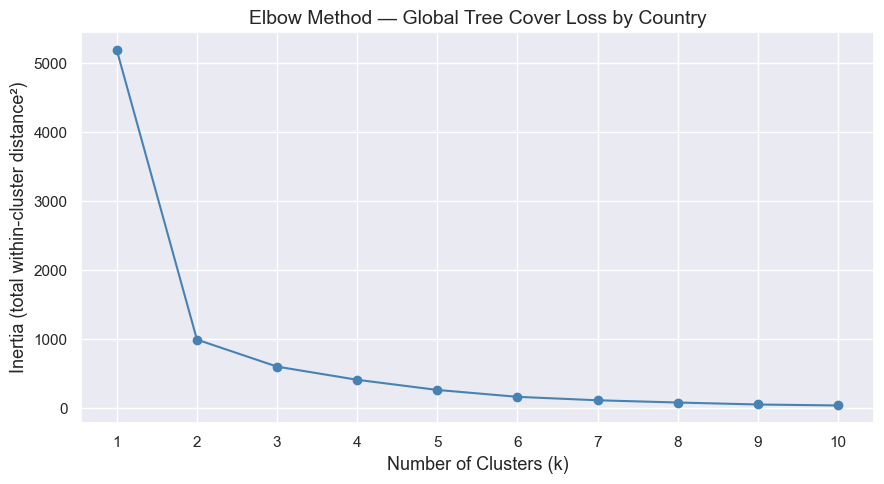

Look for the elbow — where inertia stops dropping sharply.


In [11]:
from sklearn.cluster import KMeans as SklearnKMeans

inertias = []
k_range  = range(1, 11)

for k in k_range:
    km = SklearnKMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(k_range), inertias, marker='o', color='steelblue')
plt.xlabel('Number of Clusters (k)', fontsize=13)
plt.ylabel('Inertia (total within-cluster distance²)', fontsize=13)
plt.title('Elbow Method — Global Tree Cover Loss by Country', fontsize=14)
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

print("Look for the elbow — where inertia stops dropping sharply.")


In [12]:
# Fit with chosen k
k  = 4
km = SklearnKMeans(n_clusters=k, random_state=42, n_init=10)
km.fit(X_scaled)
cluster_labels = km.labels_

df30 = df30.copy()
df30['cluster'] = cluster_labels

print('Cluster sizes:')
print(df30['cluster'].value_counts().sort_index())


Cluster sizes:
cluster
0    229
1      3
2      1
3      3
Name: count, dtype: int64


In [13]:
# Show which countries are in each cluster
for i in range(k):
    countries = df30[df30['cluster'] == i]['country'].tolist()
    preview   = ', '.join(countries[:8])
    more      = f' ... (+{len(countries)-8} more)' if len(countries) > 8 else ''
    print(f'\nCluster {i} ({len(countries)} countries):')
    print(f'  {preview}{more}')



Cluster 0 (229 countries):
  Afghanistan, Akrotiri and Dhekelia, Albania, Algeria, Andorra, Angola, Anguilla, Antigua and Barbuda ... (+221 more)

Cluster 1 (3 countries):
  Brazil, Canada, United States

Cluster 2 (1 countries):
  Russia

Cluster 3 (3 countries):
  China, Democratic Republic of the Congo, Indonesia


### Visualising Clusters with PCA

K-Means clusters in 22-dimensional space (one per year), so we can't plot
it directly. We use **PCA** to reduce to 2D for visualisation — combining
our two unsupervised methods!


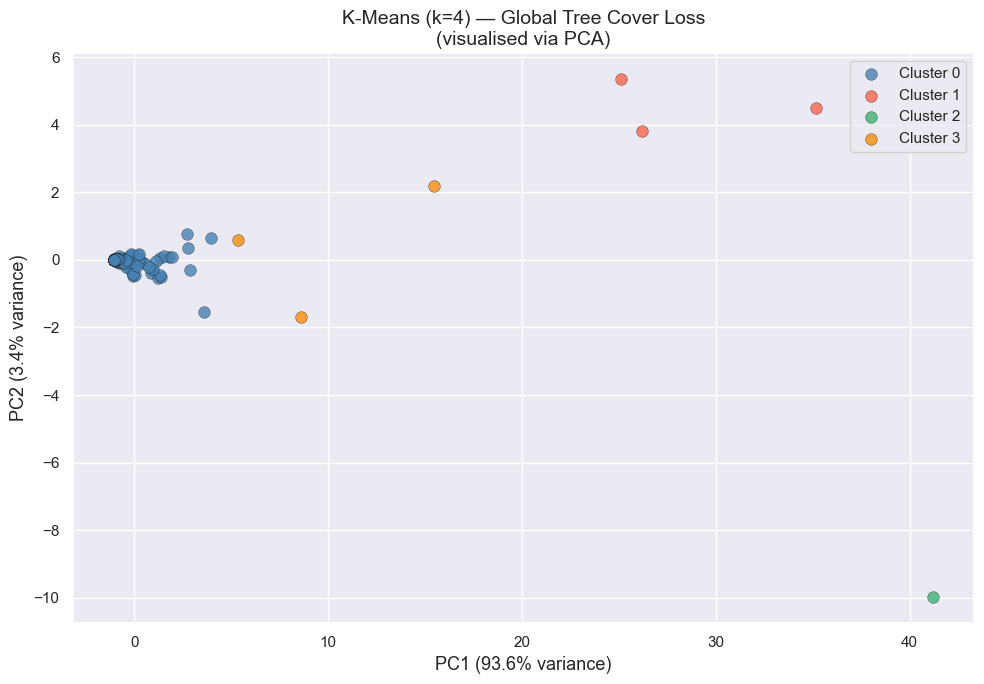

In [14]:
# Reduce to 2D with PCA for visualisation
pca  = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)
var  = pca.explained_variance_ratio_ * 100

palette = ['steelblue', 'tomato', 'mediumseagreen', 'darkorange',
           'purple', 'gold', 'pink', 'grey']

plt.figure(figsize=(10, 7))
for i in range(k):
    mask = cluster_labels == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=palette[i], label=f'Cluster {i}',
                alpha=0.8, edgecolors='k', linewidths=0.3, s=70)

plt.xlabel(f'PC1 ({var[0]:.1f}% variance)', fontsize=13)
plt.ylabel(f'PC2 ({var[1]:.1f}% variance)', fontsize=13)
plt.title(f'K-Means (k={k}) — Global Tree Cover Loss\n(visualised via PCA)', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


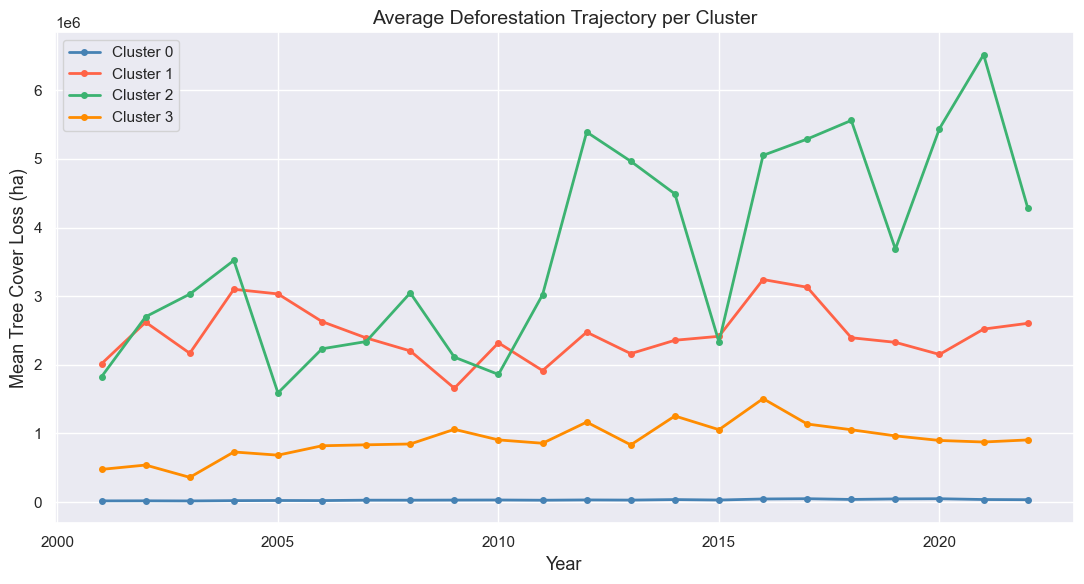

Each line shows how a cluster's average tree loss changed over time.
Clusters with spikes may have experienced fires, logging booms, etc.


In [15]:
# Plot average loss trajectory per cluster
years = [int(c.split('_')[-1]) for c in loss_cols]

plt.figure(figsize=(11, 6))
for i in range(k):
    cluster_data = X_countries[cluster_labels == i]
    mean_loss    = cluster_data.mean(axis=0)
    plt.plot(years, mean_loss, marker='o', markersize=4,
             color=palette[i], label=f'Cluster {i}', linewidth=2)

plt.xlabel('Year', fontsize=13)
plt.ylabel('Mean Tree Cover Loss (ha)', fontsize=13)
plt.title('Average Deforestation Trajectory per Cluster', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Each line shows how a cluster's average tree loss changed over time.")
print("Clusters with spikes may have experienced fires, logging booms, etc.")


---

## Part 3 — Using Our Custom KMeans Class


Inertia: 544.9
Cluster sizes: {np.int64(0): np.int64(19), np.int64(1): np.int64(4), np.int64(2): np.int64(2), np.int64(3): np.int64(211)}


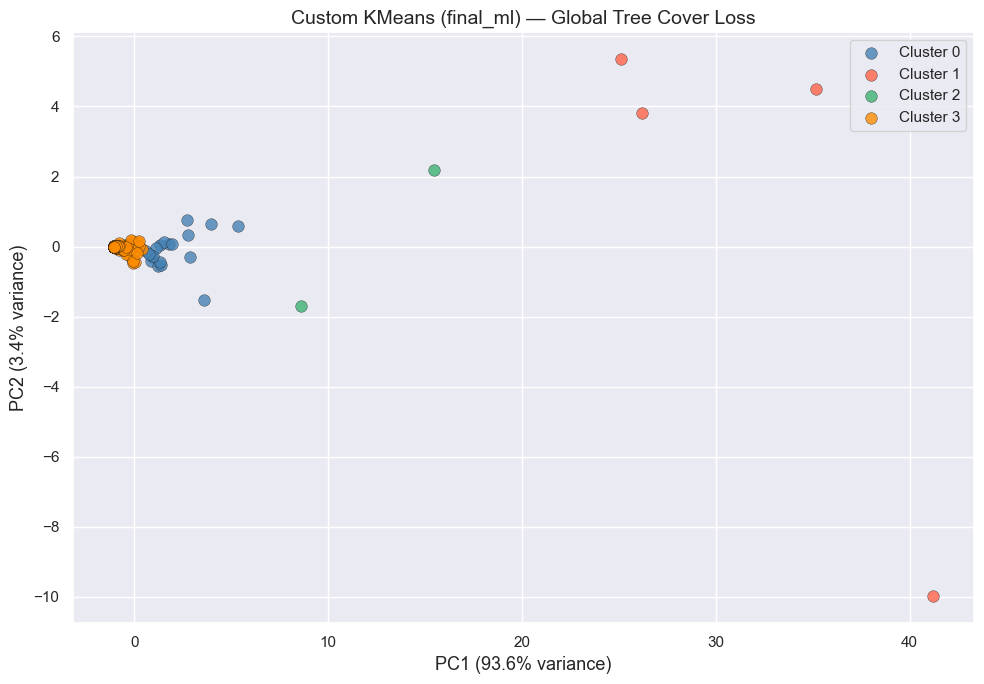

In [17]:
from final_ml.unsupervised_learning.kmeans import KMeans

my_km = KMeans(n_clusters=4, max_iter=100, random_state=42)
my_km.fit(X_scaled)
custom_labels = my_km.predict(X_scaled)

print('Inertia:', round(my_km.inertia_, 2))
print('Cluster sizes:', dict(zip(*np.unique(custom_labels, return_counts=True))))

# Visualise
plt.figure(figsize=(10, 7))
for i in range(k):
    mask = custom_labels == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=palette[i], label=f'Cluster {i}',
                alpha=0.8, edgecolors='k', linewidths=0.3, s=70)
plt.xlabel(f'PC1 ({var[0]:.1f}% variance)', fontsize=13)
plt.ylabel(f'PC2 ({var[1]:.1f}% variance)', fontsize=13)
plt.title('Custom KMeans (final_ml) — Global Tree Cover Loss', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


---

## Summary

| Concept | What it means |
|---------|--------------|
| **Unsupervised learning** | No labels — algorithm discovers structure on its own |
| **Cluster** | A group of similar data points |
| **Centroid** | The mean position of all points in a cluster |
| **Inertia** | Total within-cluster squared distance — lower = tighter clusters |
| **Elbow method** | Plot inertia vs k to choose the best number of clusters |

### Key takeaways
- Always **standardize** before K-Means — otherwise large-scale features dominate.
- Use the **elbow method** to choose k.
- K-Means is sensitive to initialisation — sklearn runs multiple times (`n_init`).
- Use **PCA** to visualize high-dimensional clusters in 2D.

**Next up:** DBSCAN Clustering!
